###**Advanced** **Data** **Science** **Final** **Term** **Project**

**Classification and Detection Anemia Disease using diffferent types of ML Algorithms**

**Roshan Paudel B01810761**

This project focuses on the classification and detection of anemia using machine learning. People with anemia are labeled as 1, while healthy people are labeled as 0. The dataset used in this study contains approximately 1000 patient records.

The main goal of this project is to develop a model for predicting anemia based on blood parameters. Focuses on the best features to give an accurate result.


Dataset: [Dataset Link](https://data.mendeley.com/datasets/y7v7ff3wpj/1)





###1. Loading Libraries and the dataset.

In [1]:
import pandas as pd           # For data manipulation
import numpy as np            # For numerical computations
import matplotlib.pyplot as plt  # For plotting charts
import seaborn as sns            # For advanced statistical plots
from sklearn.model_selection import train_test_split  # To split dataset into training and testing sets
from sklearn.preprocessing import LabelEncoder, StandardScaler  # for categorical encoding and feature scaling
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, precision_score, recall_score, f1_score)#evaluate model performance
from sklearn.linear_model import LogisticRegression, RidgeClassifier   #ML Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier     # Extra Trees for feature importance
from imblearn.over_sampling import ADASYN             #Adaptive Synthetic Sampling to balance imbalanced datasets
from collections import Counter                       # To count occurrences of each class
from sklearn.model_selection import GridSearchCV      #for tuning model hyperparameters
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
#Read the excel data file.
df = pd.read_excel('/content/drive/MyDrive/Anemia Dataset.xlsx')

In [3]:
print('Shape of data total rows and columns.')
print((df.shape))

Shape of data total rows and columns.
(1000, 9)


In [4]:
print('Top 5 Values')
df.head()

Top 5 Values


,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC,Decision_Class
0,f,32,10.9,4.26,34.2,80.2,25.5,31.8,1
1,f,45,9.6,3.64,29.9,82.1,26.4,32.2,1
2,f,38,10.1,3.70,32.4,87.6,27.4,31.3,1
3,m,37,11.0,3.93,33.6,85.3,27.9,32.7,1
4,f,50,12.1,4.16,36.5,87.9,29.2,33.2,0


In [5]:
#summary of the data
df.describe()

,Age,Hb,RBC,PCV,MCV,MCH,MCHC,Decision_Class
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,40.956000,11.568400,4.133810,32.65240,79.22000,28.143400,35.427000,0.641000
std,16.019322,1.336715,0.599695,4.85723,7.77521,3.340107,1.418162,0.479947
min,18.000000,5.500000,1.470000,10.60000,29.60000,13.300000,25.300000,0.000000
25%,28.000000,10.800000,3.767500,29.80000,75.20000,26.400000,34.900000,0.000000
50%,38.000000,11.600000,4.110000,32.80000,80.70000,28.700000,35.700000,1.000000
75%,51.250000,12.200000,4.460000,35.62500,84.42500,30.400000,36.300000,1.000000
max,96.000000,15.800000,7.410000,49.50000,104.90000,37.900000,38.100000,1.000000


In [6]:
#complete information about the data
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          1000 non-null   object 
 1   Age             1000 non-null   int64  
 2   Hb              1000 non-null   float64
 3   RBC             1000 non-null   float64
 4   PCV             1000 non-null   float64
 5   MCV             1000 non-null   float64
 6   MCH             1000 non-null   float64
 7   MCHC            1000 non-null   float64
 8   Decision_Class  1000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB


None

In [7]:
#name of the columns
df.columns

Index(['Gender', 'Age', 'Hb', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC',
       'Decision_Class'],
      dtype='object')

In [8]:
#checking the null values if it is there
df.isnull().sum()

,0
Gender,0
Age,0
Hb,0
RBC,0
PCV,0
MCV,0
MCH,0
MCHC,0
Decision_Class,0


My dataset has 1000 rows and 9 columns.

Also, one column is categorical, which is gender, 2 columns are int64 (i.e., age and decision class), and others are float64.


###2. Exploratory Data Analysis



I am going to explore data before processing it, Because i want to see the relation of the target variable and different features.

I am doing it by making copy of dataset which prevent original one.

In [9]:
df_cp = df.copy()

# Rename the values Decision_Class  and Gender columns only for visualization.
df_cp['Decision_Class'] = df_cp['Decision_Class'].replace({0: 'Non Anemic', 1: 'Anemic'})
df_cp['Gender'] = df_cp['Gender'].replace({0: 'Male', 1: 'Female'})

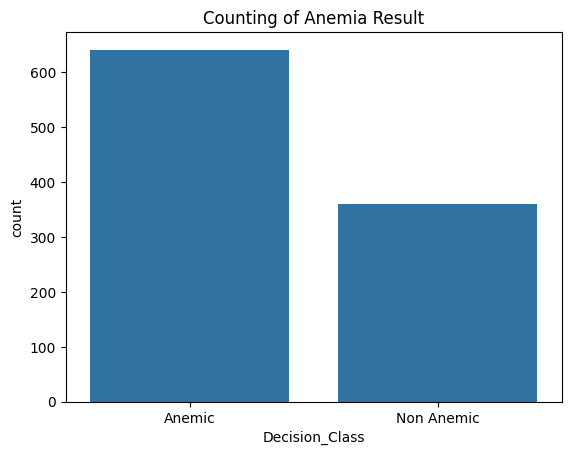

In [10]:
# Create a bar plot of the anemia result
ax = sns.countplot(x='Decision_Class', data=df_cp)
plt.title('Counting of Anemia Result')
plt.show()

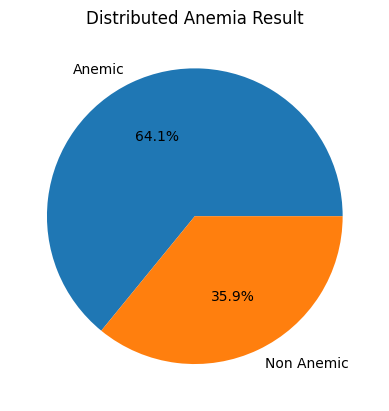

In [11]:
# Create a pie-chart of the anemia result.
result_counts = df_cp['Decision_Class'].value_counts()
plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%')
plt.title('Distributed Anemia Result')
plt.show()

/tmp/ipython-input-990946852.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female', 'Male'])


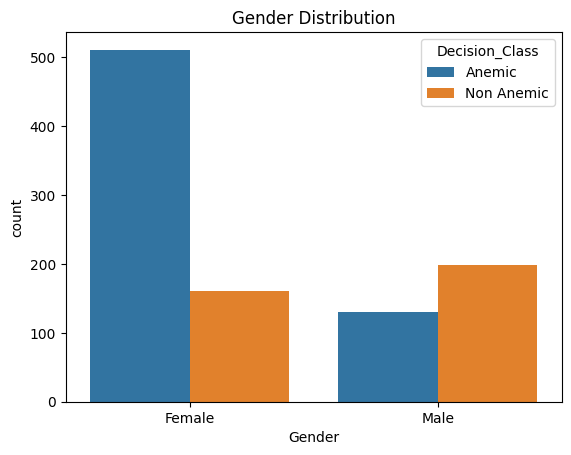

In [12]:
ax= sns.countplot(x='Gender', hue ='Decision_Class', data=df_cp)
plt.title('Gender Distribution')
ax.set_xticklabels(['Female', 'Male'])
plt.show()

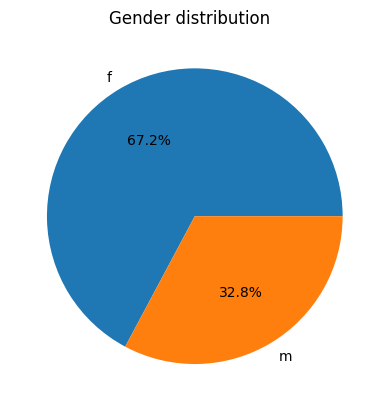

In [13]:
result_counts = df_cp['Gender'].value_counts()
plt.pie(result_counts, labels=result_counts.index, autopct='%1.1f%%')
plt.title('Gender distribution  ')
plt.show()

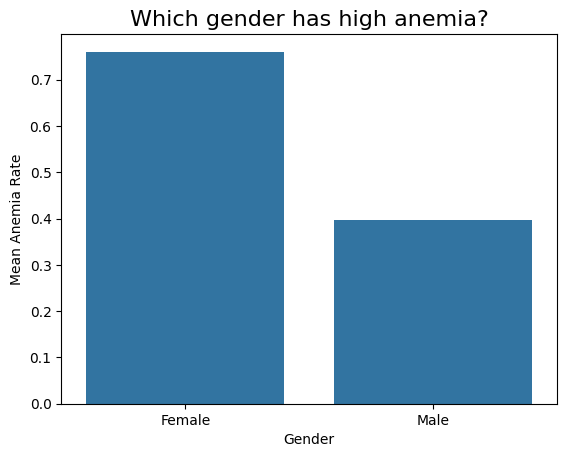

<Figure size 800x600 with 0 Axes>

In [14]:
anemia_rates = df.groupby('Gender')['Decision_Class'].mean().reset_index()
# Create the bar plot
ax = sns.barplot(x='Gender', y='Decision_Class', data=anemia_rates)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Female', 'Male'])
plt.title('Which gender has high anemia?', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Mean Anemia Rate')

plt.figure(figsize=(8, 6))
plt.show()

Now i am analyzing each features compared to the result.

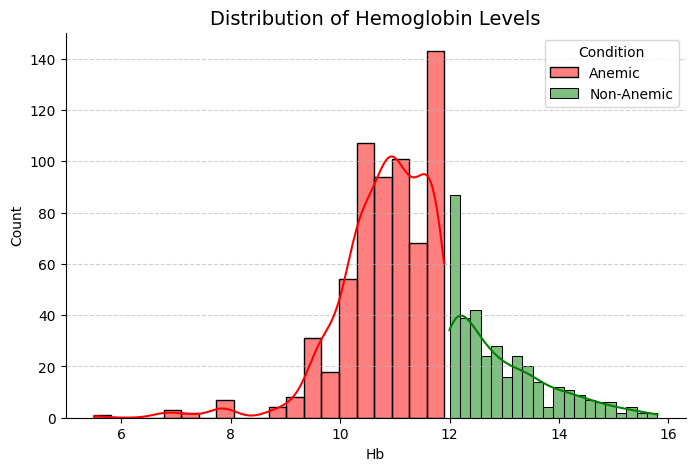

In [15]:
# Compare Hemoglobin levels between patients

plt.figure(figsize=(8,5))

sns.histplot(df[df['Decision_Class'] == 1]['Hb'], color='red', label='Anemic', kde=True, bins=20)
sns.histplot(df[df['Decision_Class'] == 0]['Hb'], color='green', label='Non-Anemic', kde=True, bins=20)

plt.title('Distribution of Hemoglobin Levels', fontsize=14)
plt.xlabel('Hb')
plt.ylabel('Count')
plt.legend(title='Condition')
plt.grid(axis='y', linestyle='--', alpha=0.6)
sns.despine()
plt.show()


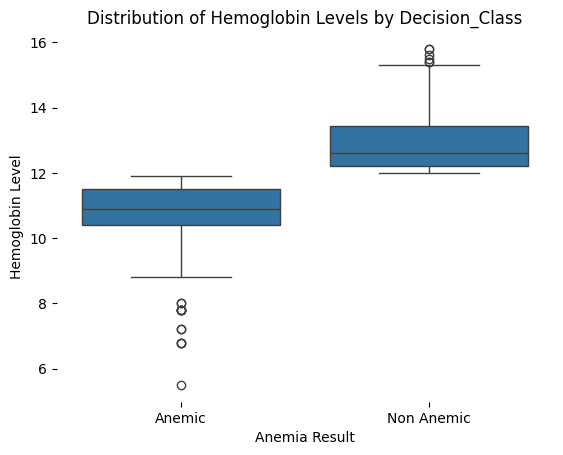

In [16]:
sns.boxplot(x='Decision_Class', y='Hb', data=df_cp)
plt.title('Distribution of Hemoglobin Levels by Decision_Class')
plt.xlabel('Anemia Result')
plt.ylabel('Hemoglobin Level')



# Remove spines
sns.despine(left=True, bottom=True)
plt.show()

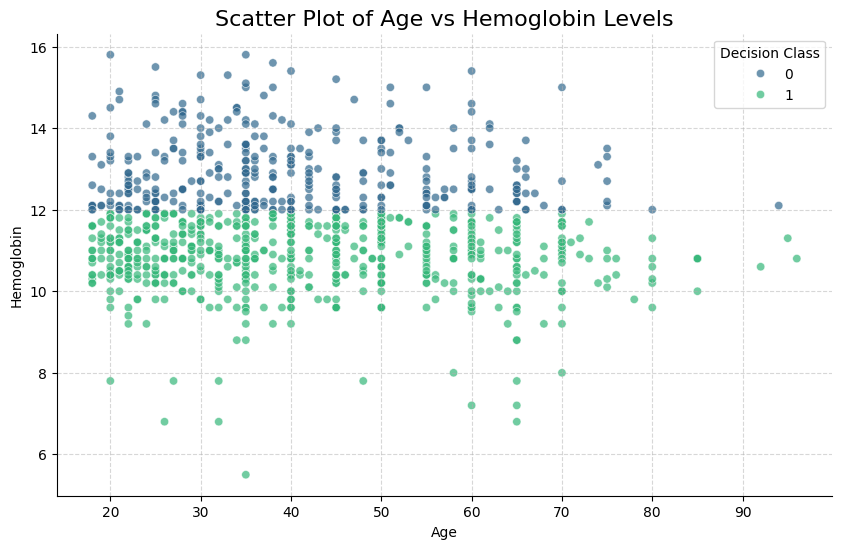

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Hb', hue='Decision_Class', data=df, palette='viridis', alpha=0.7)
plt.title('Scatter Plot of Age vs Hemoglobin Levels', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Hemoglobin')
plt.legend(title='Decision Class')
plt.grid(axis='both', linestyle='--', alpha=0.5)
sns.despine()
plt.show()

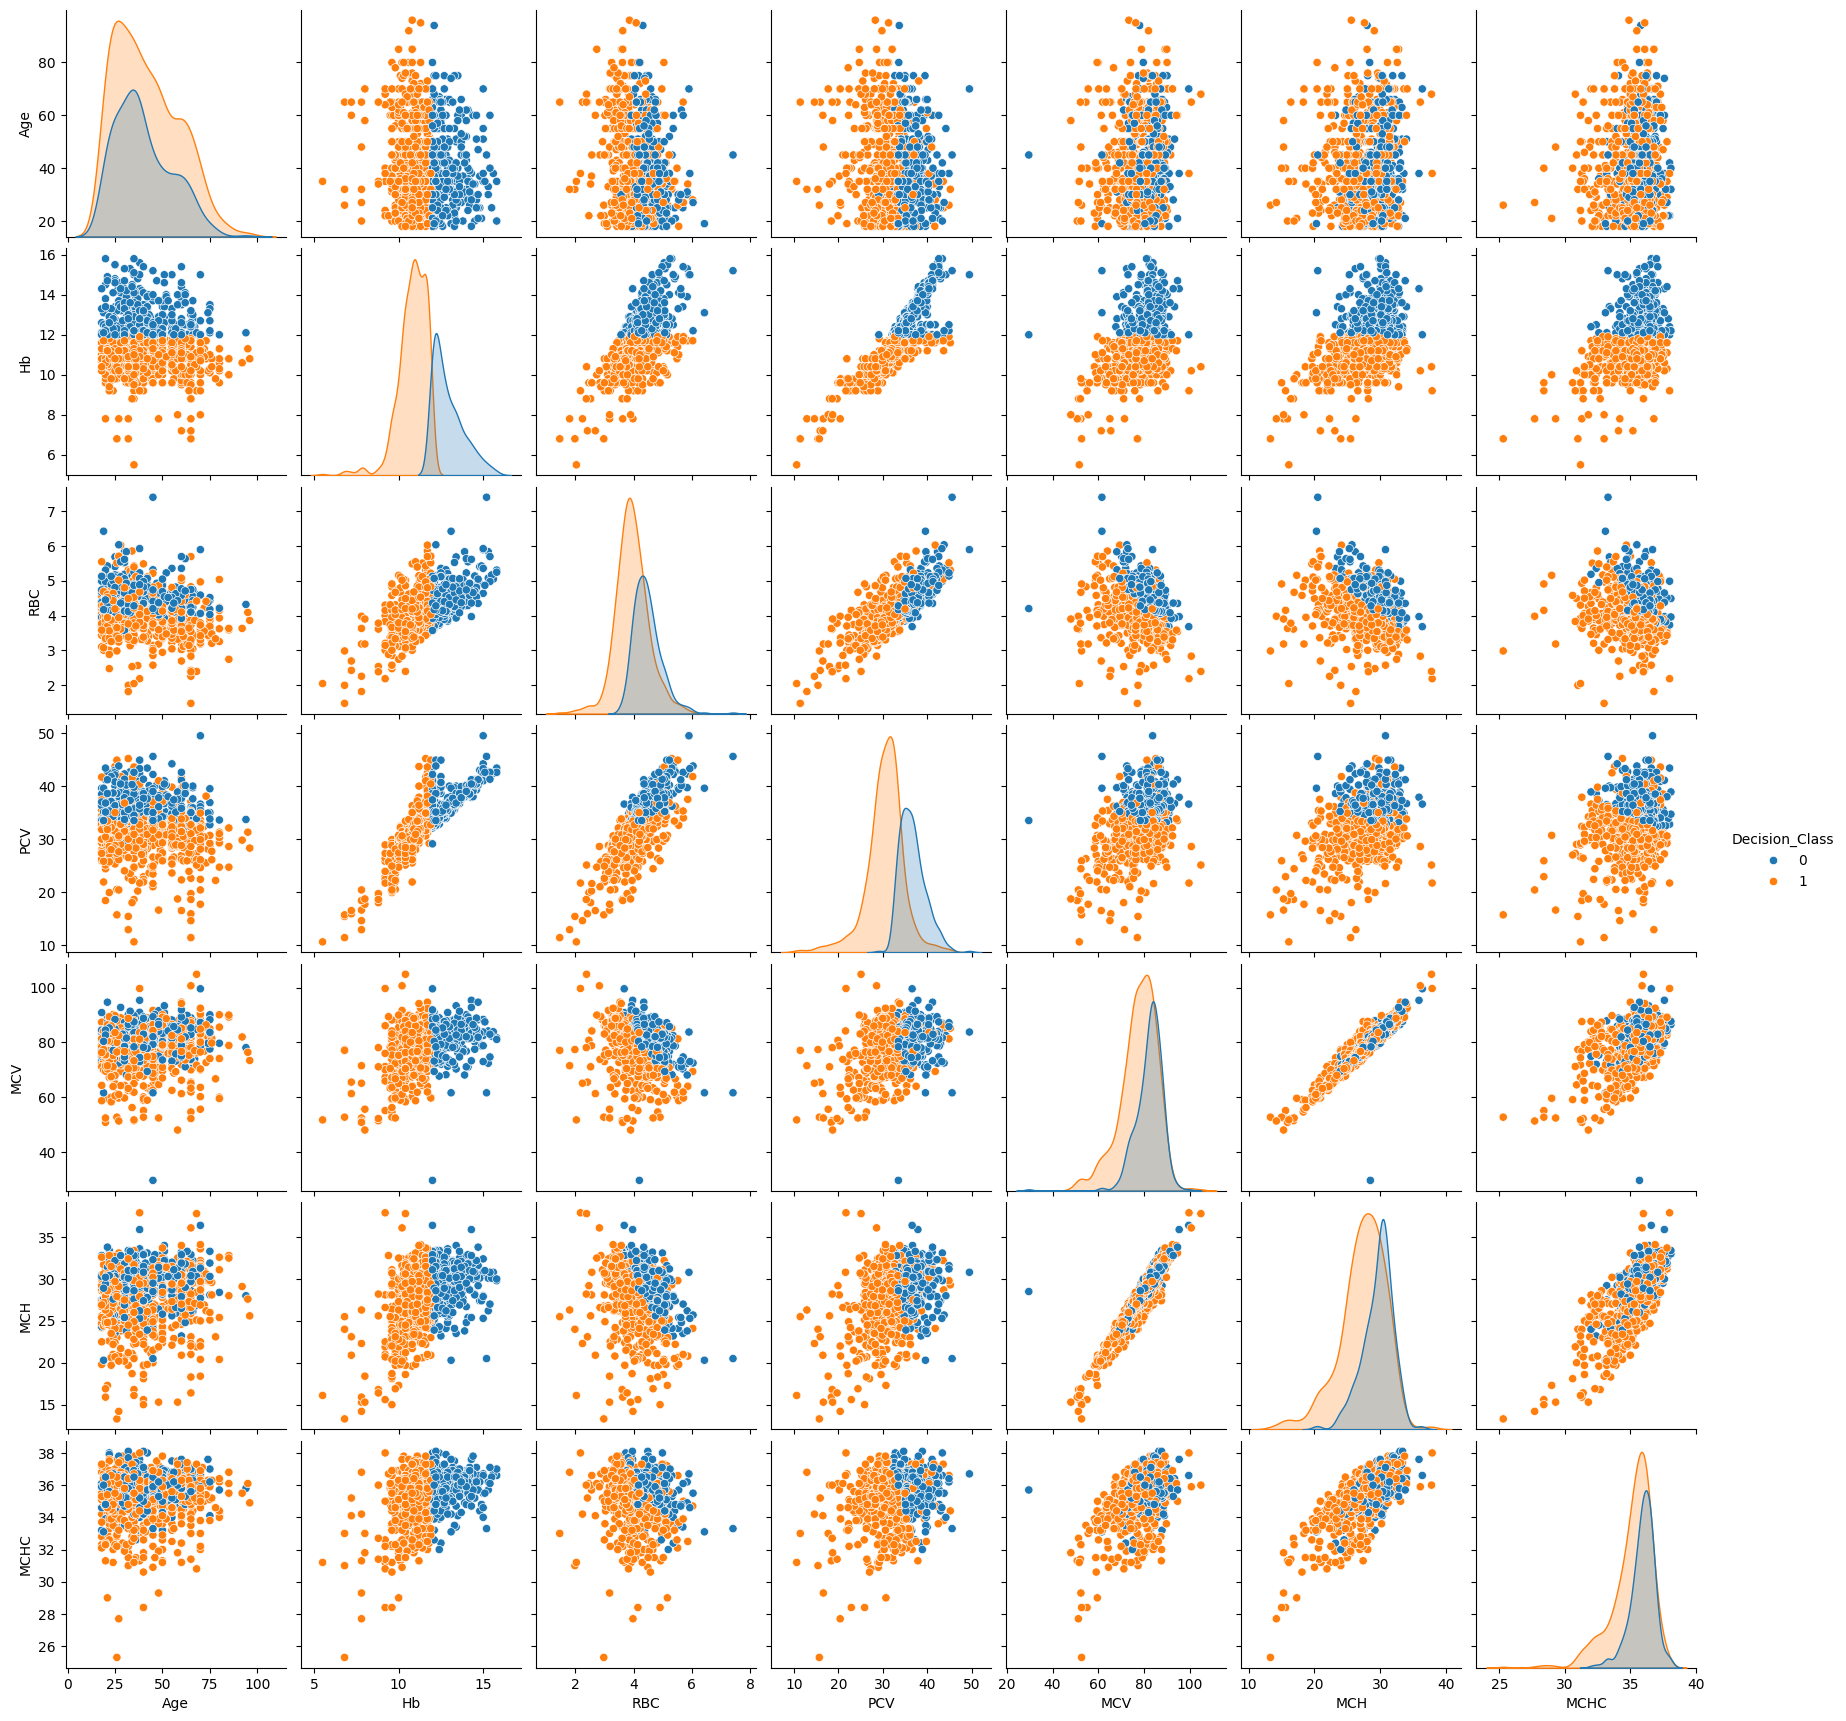

In [18]:
sns.pairplot(df,hue='Decision_Class')



I am using an Extra Tree Classifier to extract the top features for the dataset. data needs to be encoded before applying feature importances.

In [19]:
# label encoding for categorical value.
if df['Gender'].dtype == 'object':
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])

print("DataFrame after encoding 'Gender':")
display(df.head())

DataFrame after encoding 'Gender':


,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC,Decision_Class
0,0,32,10.9,4.26,34.2,80.2,25.5,31.8,1
1,0,45,9.6,3.64,29.9,82.1,26.4,32.2,1
2,0,38,10.1,3.70,32.4,87.6,27.4,31.3,1
3,1,37,11.0,3.93,33.6,85.3,27.9,32.7,1
4,0,50,12.1,4.16,36.5,87.9,29.2,33.2,0


In [20]:
X = df.iloc[:,0:8]  # independent columns
y = df.iloc[:,8]
# Extremely Randomized Trees.

model = ExtraTreesClassifier()
model.fit(X,y)

ExtraTreesClassifier()

In [21]:
print(model.feature_importances_)

[0.07930357 0.03569669 0.38221388 0.11061408 0.20608839 0.057169
 0.07386331 0.05505107]


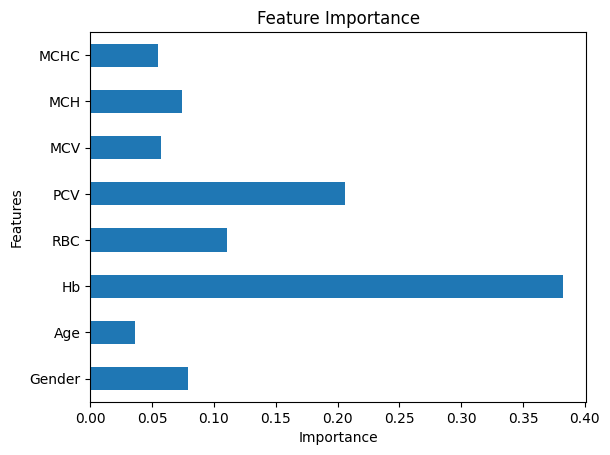

In [22]:
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)

feat_importances.plot(kind='barh')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

Now we know that Hb, PCV,RBC and Age are the best features for the model.

Feature Selection
Correlation

In [23]:
df[['Gender','Age','Hb','Decision_Class', 'RBC','PCV', 'MCV','MCH' ,'MCHC']].corr()['Decision_Class'].sort_values(ascending=False).head(10)

,Decision_Class
Decision_Class,1.000000
Age,0.056662
MCHC,-0.266055
MCV,-0.286516
MCH,-0.327836
Gender,-0.356317
RBC,-0.420792
PCV,-0.614367
Hb,-0.759145


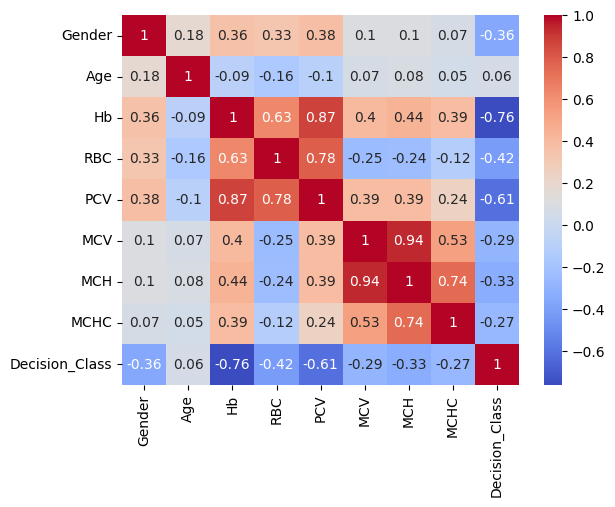

In [24]:
# create a correlation matrix
corr_matrix = df.corr().round(2)

# plot the correlation matrix using a heatmap from seaborn
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
#plt.title('Correlation Matrix', fontweight='bold')
plt.show()

Now we can clearly show that our result totally depends on HB levels. Let's do more exploration to know about data.

Using Statistical test

In [25]:
from scipy.stats import ttest_ind

# Separate data into two groups based on 'Decision_Class'
anemic_group = df[df['Decision_Class'] == 1]
non_anemic_group = df[df['Decision_Class'] == 0]

# Select features for t-tests (excluding  'Decision_Class')
numerical_features = ['Gender','Age', 'Hb', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC']

print("Independent Samples t-tests comparing Anemic vs. Non-Anemic groups:")
print("-" * 70)

# Perform t-test for each feature
for feature in numerical_features:
    t_stat, p_value = ttest_ind(anemic_group[feature], non_anemic_group[feature], nan_policy='omit')
    print(f"Feature: {feature}")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    if p_value < 0.05:
        print("  Result: Statistically Significant Difference (p < 0.05)")
    else:
        print("  Result: No Statistically Significant Difference (p >= 0.05)")
    print("-" * 20)

Independent Samples t-tests comparing Anemic vs. Non-Anemic groups:
----------------------------------------------------------------------
Feature: Gender
  T-statistic: -12.0472
  P-value: 0.0000
  Result: Statistically Significant Difference (p < 0.05)
--------------------
Feature: Age
  T-statistic: 1.7929
  P-value: 0.0733
  Result: No Statistically Significant Difference (p >= 0.05)
--------------------
Feature: Hb
  T-statistic: -36.8435
  P-value: 0.0000
  Result: Statistically Significant Difference (p < 0.05)
--------------------
Feature: RBC
  T-statistic: -14.6538
  P-value: 0.0000
  Result: Statistically Significant Difference (p < 0.05)
--------------------
Feature: PCV
  T-statistic: -24.5983
  P-value: 0.0000
  Result: Statistically Significant Difference (p < 0.05)
--------------------
Feature: MCV
  T-statistic: -9.4474
  P-value: 0.0000
  Result: Statistically Significant Difference (p < 0.05)
--------------------
Feature: MCH
  T-statistic: -10.9625
  P-value: 0.0000

###3. Data Preprocessing

Splitting data into Training and Testing samples

In [26]:
df.columns

Index(['Gender', 'Age', 'Hb', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC',
       'Decision_Class'],
      dtype='object')

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (800, 8) (800,)
Test set: (200, 8) (200,)


In [28]:
X

,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC
0,0,32,10.9,4.26,34.2,80.2,25.5,31.8
1,0,45,9.6,3.64,29.9,82.1,26.4,32.2
2,0,38,10.1,3.70,32.4,87.6,27.4,31.3
3,1,37,11.0,3.93,33.6,85.3,27.9,32.7
4,0,50,12.1,4.16,36.5,87.9,29.2,33.2
...,...,...,...,...,...,...,...,...
995,0,32,10.4,4.49,28.4,63.2,21.2,33.5
996,1,48,13.7,4.37,37.8,86.6,31.4,36.2
997,1,19,12.1,4.17,33.5,80.4,28.9,36.0
998,0,35,12.2,4.28,33.5,78.4,28.6,36.5


Scaling Features

In [29]:
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

In [30]:
# Identify numerical columns in X that need scaling (excluding 'Gender' which is already encoded)
numerical_cols = ['Hb', 'RBC', 'PCV']

# Apply StandardScaler
# Fit on X_train and transform both X_train and X_test
X_train[numerical_cols] = scaler_standard.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler_standard.transform(X_test[numerical_cols])

print("X_train after scaling numerical features:")
display(X_train.head())
print("\nX_test after scaling numerical features:")
display(X_test.head())

X_train after scaling numerical features:


,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC
175,0,20,0.012055,-0.541551,-0.048083,85.3,30.4,35.7
818,0,45,-0.289328,-0.524724,-0.069383,84.8,30.8,36.3
677,0,45,-0.440020,0.501754,-0.261077,71.2,24.9,35.0
952,1,32,1.066897,0.316652,0.910388,85.7,30.1,35.2
200,0,47,-0.590712,-1.214652,-0.537969,88.7,31.7,35.7



X_test after scaling numerical features:


,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC
37,0,55,-0.440020,-0.154519,0.101012,82.1,27.3,33.2
726,0,40,0.012055,0.215687,0.015815,77.0,27.3,35.5
846,1,21,-0.213982,0.787822,-0.069383,70.3,24.6,35.0
295,1,38,1.292935,0.451272,0.867790,83.5,30.3,36.3
924,0,26,-0.892095,-1.214652,-1.155651,80.0,28.2,35.2


In [31]:
# Quick sanity check with the shapes of Training and testing datasets
print("Shape of training data (X_train):", X_train.shape)
print("Shape of training labels (y_train):", y_train.shape)
print("Shape of testing data (X_test):", X_test.shape)
print("Shape of testing labels (y_test):", y_test.shape)

Shape of training data (X_train): (800, 8)
Shape of training labels (y_train): (800,)
Shape of testing data (X_test): (200, 8)
Shape of testing labels (y_test): (200,)


Simulating synthetic data (ADASYN) for logistic regression to find out the model performance on balanced data.

In [32]:
from collections import Counter
from imblearn.over_sampling import ADASYN

print('Original dataset shape %s' % Counter(y_train))

adasyn = ADASYN(random_state=42)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
print('Resampled dataset shape %s' % Counter(y_train_adasyn))

Original dataset shape Counter({1: 514, 0: 286})
Resampled dataset shape Counter({1: 514, 0: 490})


###4. Modelling

Model Evaluation

Classification Models

Logistic Regression

Decision Trees

Random Forest

Naive Bayes Classifier

SVM

KNN

Logistic Regression

Logistic Regression Results:
Accuracy: 0.975

Confusion Matrix:
 [[ 72   1]
 [  4 123]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        73
           1       0.99      0.97      0.98       127

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



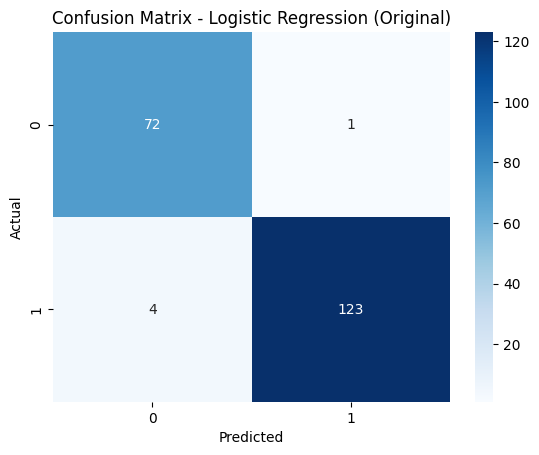

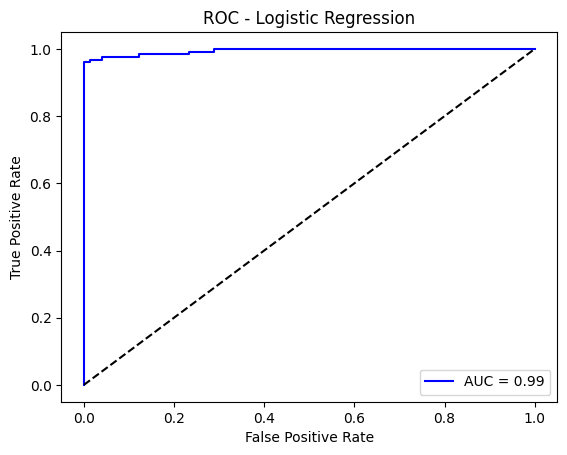

In [33]:
# Train Logistic Regression
log_reg = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

# Evaluation
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Original)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='blue')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Logistic Regression")
plt.legend()
plt.show()


Original dataset shape: Counter({1: 514, 0: 286})
Resampled dataset shape (ADASYN): Counter({1: 514, 0: 490})
Logistic Regression (ADASYN) Results:
Accuracy: 0.975

Confusion Matrix:
 [[ 73   0]
 [  5 122]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        73
           1       1.00      0.96      0.98       127

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200



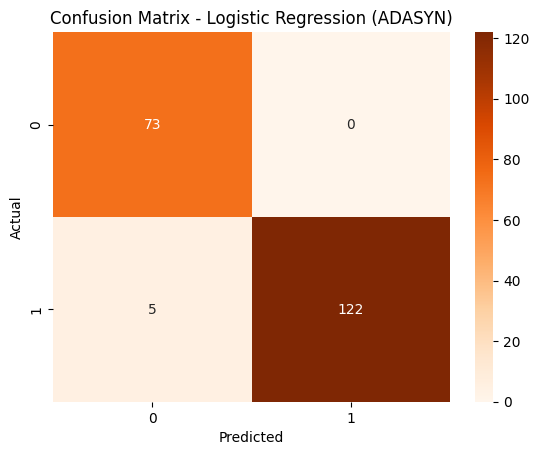

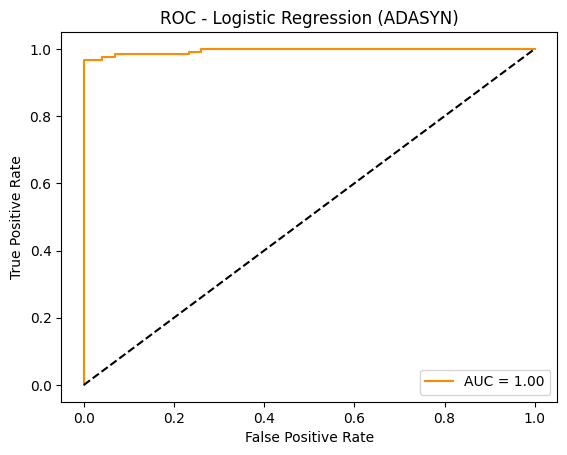

In [34]:

# Apply ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Original dataset shape:", Counter(y_train))
print("Resampled dataset shape (ADASYN):", Counter(y_train_adasyn))

# Train Logistic Regression on ADASYN data
log_reg_adasyn = LogisticRegression(max_iter=500, solver='lbfgs', random_state=42)
log_reg_adasyn.fit(X_train_adasyn, y_train_adasyn)
y_pred_lr_adasyn = log_reg_adasyn.predict(X_test)

# Evaluation
print("Logistic Regression (ADASYN) Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_adasyn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_adasyn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_adasyn))

# Confusion Matrix Plot
sns.heatmap(confusion_matrix(y_test, y_pred_lr_adasyn), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Logistic Regression (ADASYN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_prob_lr_adasyn = log_reg_adasyn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr_adasyn)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color='darkorange')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC - Logistic Regression (ADASYN)")
plt.legend()
plt.show()


Now i am using Different types of Logistic Regression models

Ridge logistic Classification

Ridge Classifier Results:
Accuracy: 0.905

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.77      0.85        73
           1       0.88      0.98      0.93       127

    accuracy                           0.91       200
   macro avg       0.92      0.88      0.89       200
weighted avg       0.91      0.91      0.90       200



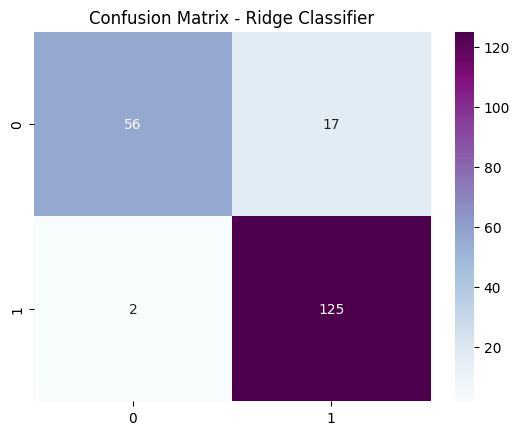

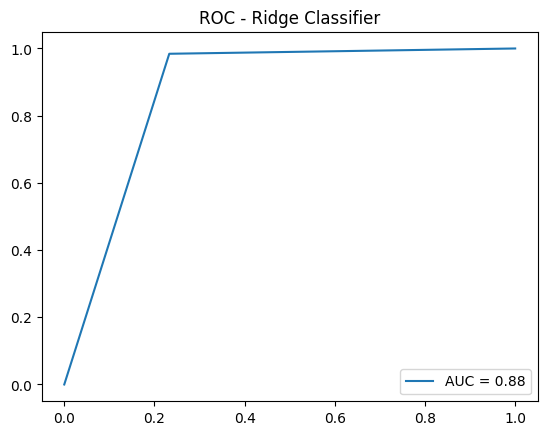

In [35]:
# Ridge = Logistic Regression with L2 penalty
ridge = RidgeClassifier(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Ridge Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_ridge))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ridge))

sns.heatmap(confusion_matrix(y_test, y_pred_ridge), annot=True, fmt='d', cmap='BuPu')
plt.title("Confusion Matrix - Ridge Classifier")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_ridge)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - Ridge Classifier")
plt.show()


Lasso Logistic Regression

Lasso Logistic Regression Results:
Accuracy: 0.99

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        73
           1       1.00      0.98      0.99       127

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



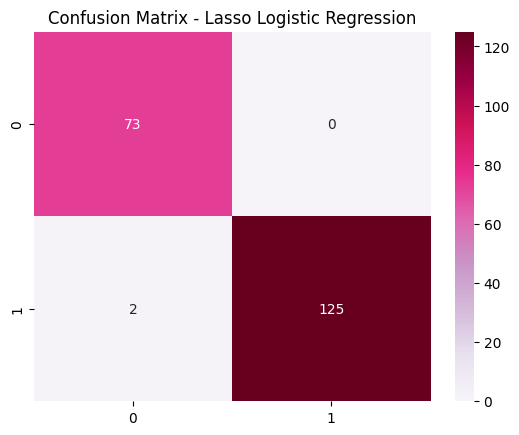

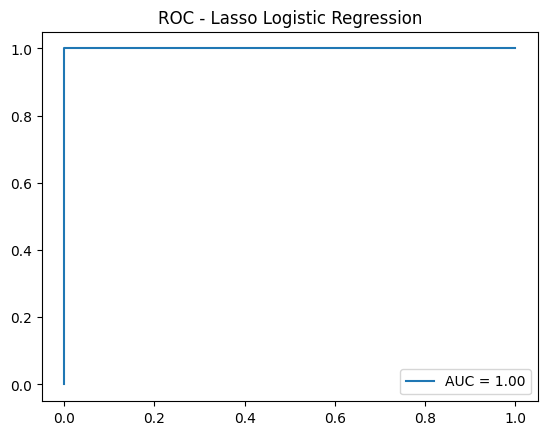

In [36]:
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=500,
    random_state=42
)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Lasso Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lasso))

sns.heatmap(confusion_matrix(y_test, y_pred_lasso), annot=True, fmt='d', cmap='PuRd')
plt.title("Confusion Matrix - Lasso Logistic Regression")
plt.show()

# ROC Curve
y_prob_lasso = lasso.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lasso)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - Lasso Logistic Regression")
plt.show()


Elastic Net Logistic Regression

Elastic Net Logistic Regression Results:
Accuracy: 0.925

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90        73
           1       0.93      0.95      0.94       127

    accuracy                           0.93       200
   macro avg       0.92      0.91      0.92       200
weighted avg       0.92      0.93      0.92       200



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


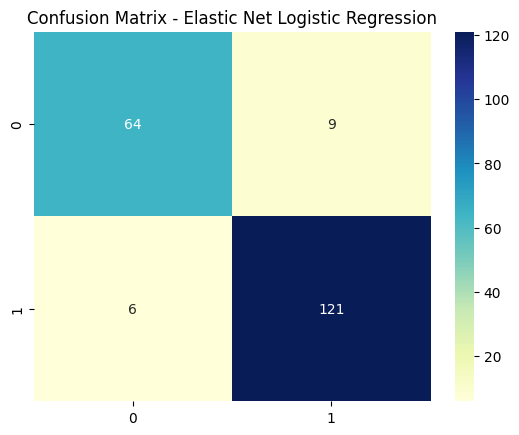

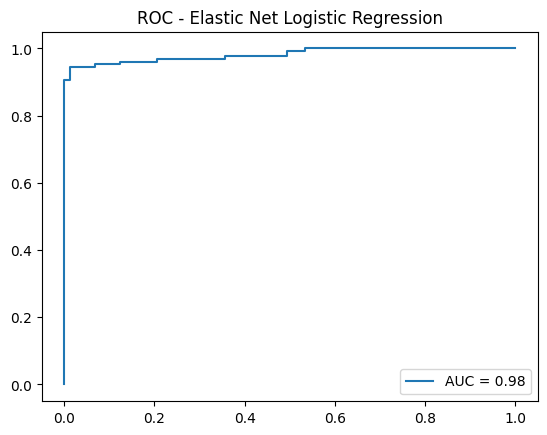

In [37]:
elastic = LogisticRegression(
    penalty='elasticnet',
    solver='saga',        # saga supports elasticnet
    l1_ratio=0.5,         # mix between L1 and L2
    max_iter=1000,
    random_state=42
)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

print("Elastic Net Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_elastic))
print("\nClassification Report:\n", classification_report(y_test, y_pred_elastic))

sns.heatmap(confusion_matrix(y_test, y_pred_elastic), annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - Elastic Net Logistic Regression")
plt.show()

# ROC Curve
y_prob_elastic = elastic.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_elastic)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - Elastic Net Logistic Regression")
plt.show()


Building different models with different balanced datasets

Decision Tree Classifier

Decision Tree Results:
Accuracy: 1.0

Confusion Matrix:
 [[ 73   0]
 [  0 127]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00       127

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



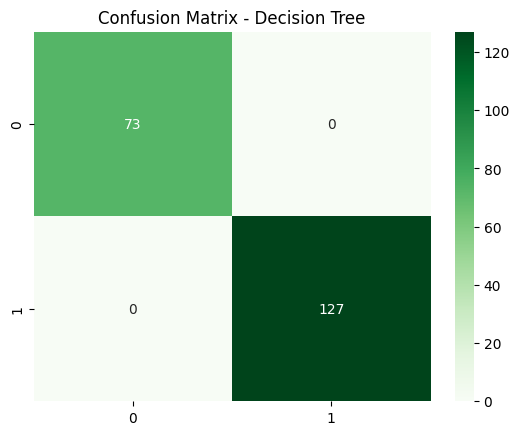

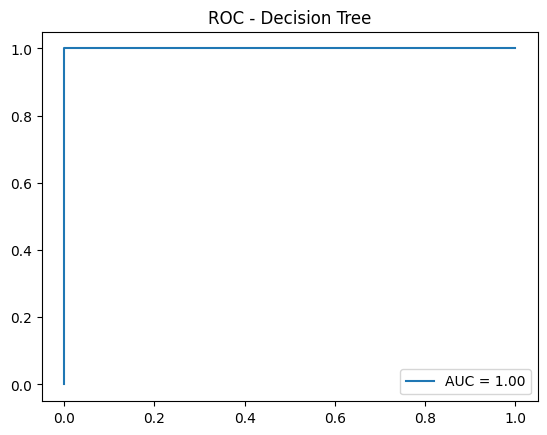

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

dt = DecisionTreeClassifier(random_state=42, max_depth=3)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# ROC
y_prob_dt = dt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - Decision Tree")
plt.show()

Random Forest Classifier

Random Forest Results:
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00       127

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



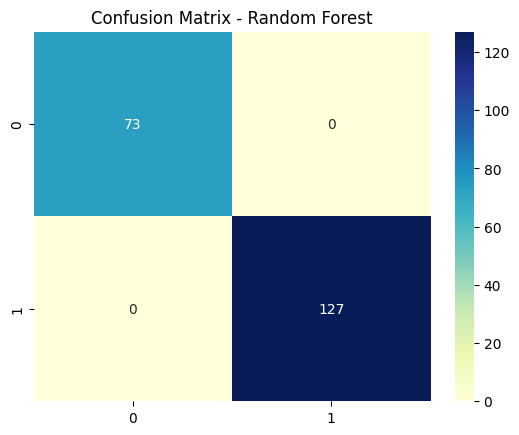

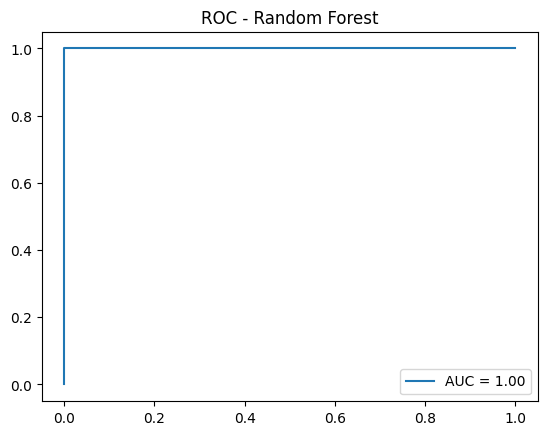

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ROC
y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - Random Forest")
plt.show()


XG Boost Clssifier

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [23:54:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Results:
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00       127

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



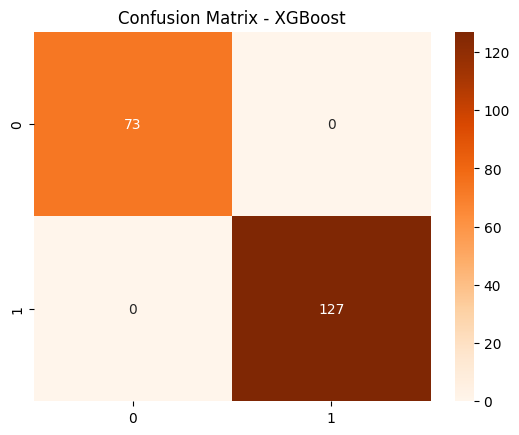

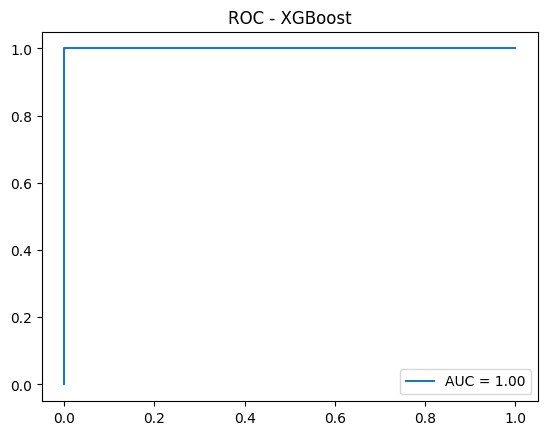

In [40]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# ROC
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - XGBoost")
plt.show()


Support Vector Machine

SVM Results:
Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.63      0.72        73
           1       0.82      0.94      0.87       127

    accuracy                           0.82       200
   macro avg       0.83      0.78      0.80       200
weighted avg       0.83      0.82      0.82       200



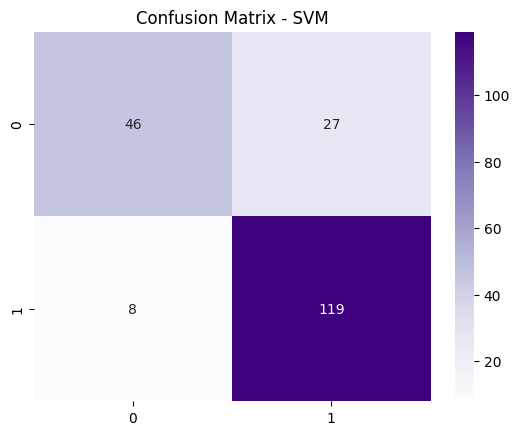

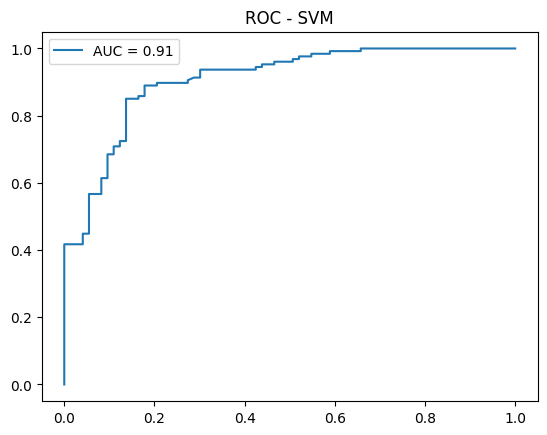

In [41]:
from sklearn.svm import SVC

svm = SVC(probability=True, gamma='auto', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - SVM")
plt.show()

# ROC
y_prob_svm = svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
from sklearn.metrics import auc # Re-import auc to ensure it's the function
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - SVM")
plt.show()


K Neighbors Classifier

KNN Results:
Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.66      0.71        73
           1       0.82      0.88      0.85       127

    accuracy                           0.80       200
   macro avg       0.79      0.77      0.78       200
weighted avg       0.80      0.80      0.80       200



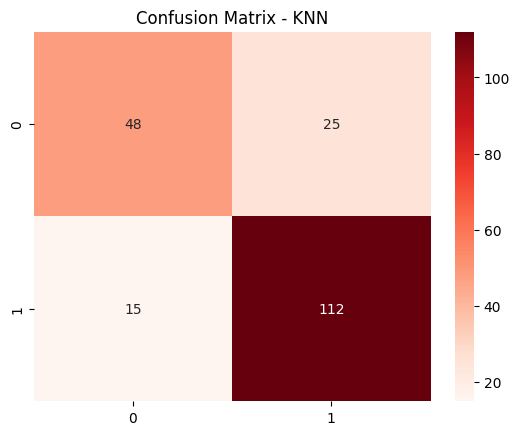

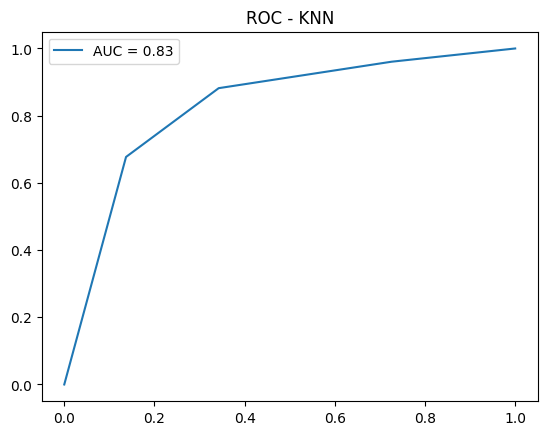

In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - KNN")
plt.show()

# ROC
y_prob_knn = knn.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
from sklearn.metrics import auc # Re-import auc to ensure it's the function
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - KNN")
plt.show()


 Gaussian Naive Bayes Classifier

Naive Bayes Results:
Accuracy: 0.92

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.93      0.89        73
           1       0.96      0.91      0.94       127

    accuracy                           0.92       200
   macro avg       0.91      0.92      0.92       200
weighted avg       0.92      0.92      0.92       200



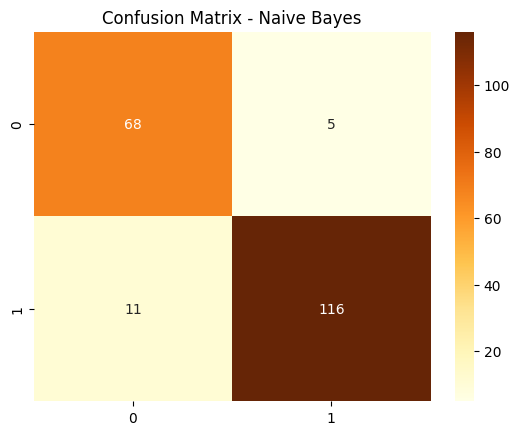

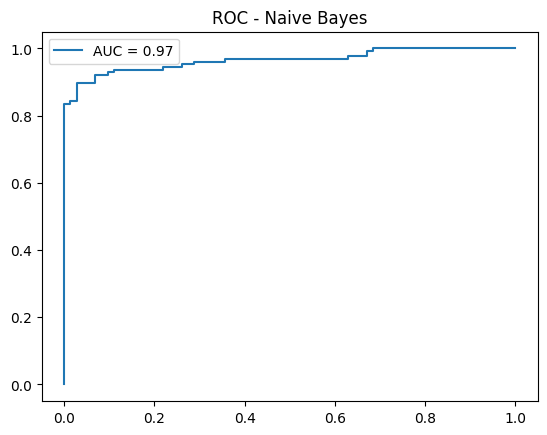

In [43]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='YlOrBr')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# ROC
y_prob_nb = nb.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.legend()
plt.title("ROC - Naive Bayes")
plt.show()


In [44]:
from sklearn.linear_model import RidgeClassifier, SGDClassifier


Performances measures of various Models.

In [45]:
results = [
    ("Logistic Regression", y_test, y_pred_lr, log_reg.predict_proba(X_test)[:, 1]),
    ("Logistic Regression (ADASYN)", y_test, y_pred_lr_adasyn, log_reg_adasyn.predict_proba(X_test)[:, 1]),
    ("Decision Tree", y_test, y_pred_dt, dt.predict_proba(X_test)[:, 1]),
    ("Random Forest", y_test, y_pred_rf, rf.predict_proba(X_test)[:, 1]),
    ("XGBoost", y_test, y_pred_xgb, xgb.predict_proba(X_test)[:, 1]),
    ("SVM", y_test, y_pred_svm, svm.predict_proba(X_test)[:, 1]),
    ("KNN", y_test, y_pred_knn, knn.predict_proba(X_test)[:, 1]),
    ("Naive Bayes", y_test, y_pred_nb, nb.predict_proba(X_test)[:, 1]),
    ("Ridge Classifier", y_test, y_pred_ridge, y_pred_ridge), # Note: RidgeClassifier does not have predict_proba, so using decision function or raw predictions is an alternative if actual probabilities are needed.
    ("Lasso Logistic Regression", y_test, y_pred_lasso, lasso.predict_proba(X_test)[:, 1]),
    ("Elastic Net Logistic Regression", y_test, y_pred_elastic, elastic.predict_proba(X_test)[:, 1]),
]

# Compute metrics
performance_data = []
for name, y_true, y_pred, y_prob in results:
    try:
        accuracy = accuracy_score(y_true, y_pred)
        # Rename the variable to avoid conflict with the imported auc function
        roc_auc_score_value = roc_auc_score(y_true, y_prob)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        # Use the renamed variable in the list append
        performance_data.append([name, accuracy, roc_auc_score_value, precision, recall, f1])
    except Exception as e:
        print(f"Error processing {name}: {e}")

#Create DataFrame ---
performance_df = pd.DataFrame(performance_data,
                              columns=["Model", "Accuracy", "AUC", "Precision", "Recall", "F1 Score"])
performance_df = performance_df.round(3).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("Performance Measures of Various Models:\n")
print(performance_df)


Performance Measures of Various Models:

                              Model  Accuracy    AUC  Precision  Recall  \
0                     Decision Tree     1.000  1.000      1.000   1.000   
1                           XGBoost     1.000  1.000      1.000   1.000   
2                     Random Forest     1.000  1.000      1.000   1.000   
3         Lasso Logistic Regression     0.990  1.000      1.000   0.984   
4               Logistic Regression     0.975  0.994      0.992   0.969   
5      Logistic Regression (ADASYN)     0.975  0.995      1.000   0.961   
6   Elastic Net Logistic Regression     0.925  0.982      0.931   0.953   
7                       Naive Bayes     0.920  0.965      0.959   0.913   
8                  Ridge Classifier     0.905  0.876      0.880   0.984   
9                               SVM     0.825  0.907      0.815   0.937   
10                              KNN     0.800  0.828      0.818   0.882   

    F1 Score  
0      1.000  
1      1.000  
2      1.000 

Model Comparison

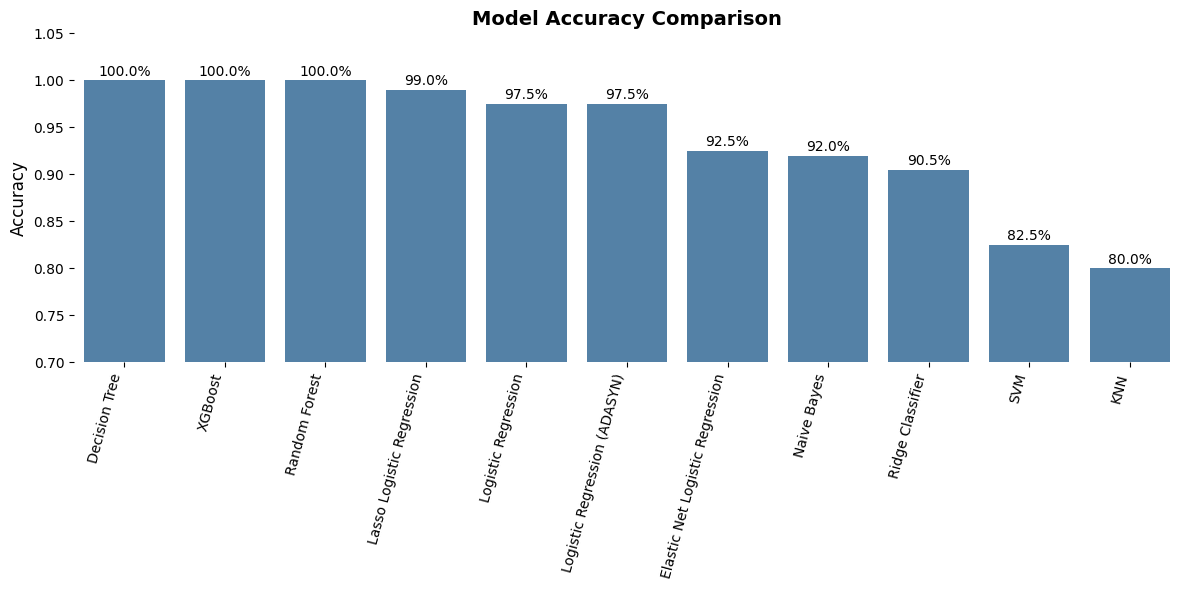

In [46]:
# accuracy values
model_names = performance_df['Model'].tolist()
accuracies = performance_df['Accuracy'].tolist()

# Create dataframe
acc_df = pd.DataFrame({'Model': model_names, 'Accuracy': accuracies})

# Plot
plt.figure(figsize=(12,6))
sns.barplot(data=acc_df, x='Model', y='Accuracy', color='steelblue')

plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12)
plt.xlabel("")
plt.ylim(0.7, 1.05) # Adjusted y-axis limit to include SVM and KNN
plt.xticks(rotation=75, ha='right')

# Add accuracy labels
for i, v in enumerate(acc_df['Accuracy']):
    plt.text(i, v + 0.005, f"{v*100:.1f}%", ha='center', fontsize=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


I am using GridSearchCV for optimal result.

In [47]:
# Define classifiers (11 models)
classifiers_ = [
    DecisionTreeClassifier(random_state=42),
    XGBClassifier(random_state=42, eval_metric='logloss'),
    RandomForestClassifier(random_state=42),
    LogisticRegression(penalty='l1', solver='liblinear', max_iter=500, random_state=42),  # Lasso
    LogisticRegression(max_iter=500, random_state=42),  # Logistic Regression
    LogisticRegression(max_iter=500, random_state=42),  # Logistic Regression (ADASYN)
    SVC(probability=True, random_state=42),
    KNeighborsClassifier(),
    RidgeClassifier(random_state=42),
    GaussianNB(),
    LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=500, random_state=42)  # Elastic Net
]

# Parameter grids
param_grids = [
    {'criterion': ['gini', 'entropy'], 'max_depth': range(2, 10)},  # Decision Tree
    {'n_estimators': [50, 100, 200], 'max_depth': [2, 4, 6], 'learning_rate': [0.01, 0.1, 0.3]},  # XGBoost
    {'n_estimators': [50, 100, 200], 'max_depth': range(2, 10)},  # Random Forest
    {'C': [0.1, 1, 10]},  # Lasso
    {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},  # Logistic Regression
    {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},  # Logistic Regression (ADASYN)
    {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},  # SVM
    {'n_neighbors': list(range(2, 20, 2)), 'algorithm': ['auto', 'ball_tree', 'kd_tree']},  # KNN
    {'alpha': [0.1, 1.0, 10.0]},  # Ridge
    {},  # Naive Bayes
    {'C': [0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}  # Elastic Net
]

# Model names
model_names = [
    'Decision Tree', 'XGBoost', 'Random Forest', 'Lasso Logistic Regression',
    'Logistic Regression', 'Logistic Regression (ADASYN)', 'SVM',
    'KNN', 'Ridge Classifier', 'Naive Bayes', 'Elastic Net Logistic Regression'
]

# Run GridSearchCV
grid_results = []

print("Running GridSearchCV for 11 Models...\n")

for clf, params, name in zip(classifiers_, param_grids, model_names):
    print(f" {name} in progress...")

    # ADASYN model uses resampled data
    if name == 'Logistic Regression (ADASYN)':
        X_train_used, y_train_used = X_train_adasyn, y_train_adasyn
    else:
        X_train_used, y_train_used = X_train, y_train

    grid = GridSearchCV(clf, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_used, y_train_used)
    y_pred = grid.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f".  {name} complete")
    print(f"   Best Params: {grid.best_params_}")
    print(f"   CV Accuracy: {grid.best_score_:.4f}")
    print(f"   Accuracy: {acc:.4f}")
    print(f"   F1 Score: {f1:.4f}\n")

    grid_results.append([name, acc, f1, grid.best_score_, grid.best_params_])

# Create DataFrame for results
grid_df = pd.DataFrame(grid_results, columns=["Model", "Accuracy", "F1 Score", "CV Accuracy", "Best Params"])
grid_df = grid_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nGrid Search Summary:\n")
print(grid_df)


Running GridSearchCV for 11 Models...

 Decision Tree in progress...
.  Decision Tree complete
   Best Params: {'criterion': 'gini', 'max_depth': 2}
   CV Accuracy: 1.0000
   Accuracy: 1.0000
   F1 Score: 1.0000

 XGBoost in progress...
.  XGBoost complete
   Best Params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 50}
   CV Accuracy: 1.0000
   Accuracy: 1.0000
   F1 Score: 1.0000

 Random Forest in progress...
.  Random Forest complete
   Best Params: {'max_depth': 2, 'n_estimators': 50}
   CV Accuracy: 1.0000
   Accuracy: 1.0000
   F1 Score: 1.0000

 Lasso Logistic Regression in progress...
.  Lasso Logistic Regression complete
   Best Params: {'C': 10}
   CV Accuracy: 0.9975
   Accuracy: 1.0000
   F1 Score: 1.0000

 Logistic Regression in progress...
.  Logistic Regression complete
   Best Params: {'C': 10, 'solver': 'lbfgs'}
   CV Accuracy: 0.9963
   Accuracy: 0.9800
   F1 Score: 0.9841

 Logistic Regression (ADASYN) in progress...
.  Logistic Regression (ADASYN) comple

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [48]:
grid_df

,Model,Accuracy,F1 Score,CV Accuracy,Best Params
0,Decision Tree,1.000,1.000000,1.000000,"{'criterion': 'gini', 'max_depth': 2}"
1,XGBoost,1.000,1.000000,1.000000,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est..."
2,Random Forest,1.000,1.000000,1.000000,"{'max_depth': 2, 'n_estimators': 50}"
3,Lasso Logistic Regression,1.000,1.000000,0.997500,{'C': 10}
4,SVM,0.990,0.992063,0.995000,"{'C': 10, 'kernel': 'linear'}"
5,Logistic Regression (ADASYN),0.985,0.988048,0.997015,"{'C': 10, 'solver': 'lbfgs'}"
6,Logistic Regression,0.980,0.984127,0.996250,"{'C': 10, 'solver': 'lbfgs'}"
7,Naive Bayes,0.920,0.935484,0.927500,{}
8,Ridge Classifier,0.905,0.929368,0.923750,{'alpha': 0.1}
9,Elastic Net Logistic Regression,0.905,0.927203,0.938750,"{'C': 0.1, 'l1_ratio': 0.8}"


###5. Evaluation

Now we can compare this result with the original one.

In [49]:
performance_df

,Model,Accuracy,AUC,Precision,Recall,F1 Score
0,Decision Tree,1.000,1.000,1.000,1.000,1.000
1,XGBoost,1.000,1.000,1.000,1.000,1.000
2,Random Forest,1.000,1.000,1.000,1.000,1.000
3,Lasso Logistic Regression,0.990,1.000,1.000,0.984,0.992
4,Logistic Regression,0.975,0.994,0.992,0.969,0.980
5,Logistic Regression (ADASYN),0.975,0.995,1.000,0.961,0.980
6,Elastic Net Logistic Regression,0.925,0.982,0.931,0.953,0.942
7,Naive Bayes,0.920,0.965,0.959,0.913,0.935
8,Ridge Classifier,0.905,0.876,0.880,0.984,0.929
9,SVM,0.825,0.907,0.815,0.937,0.872


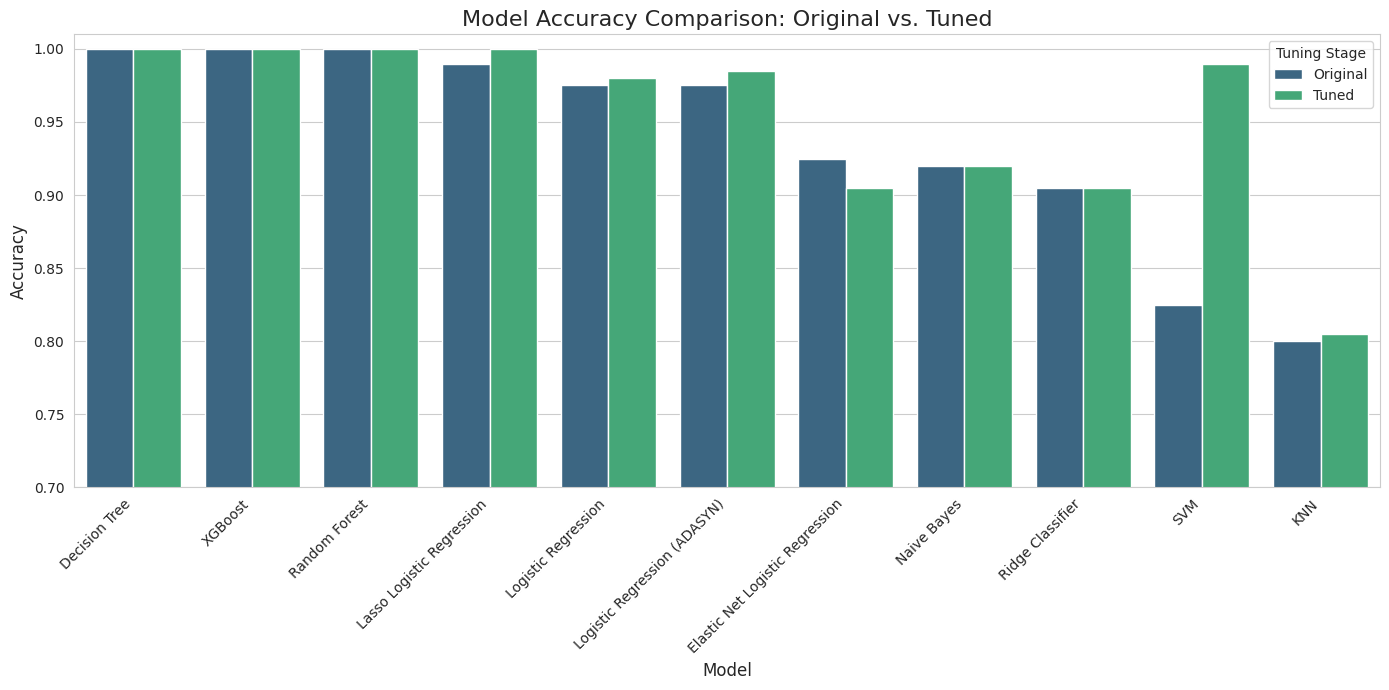

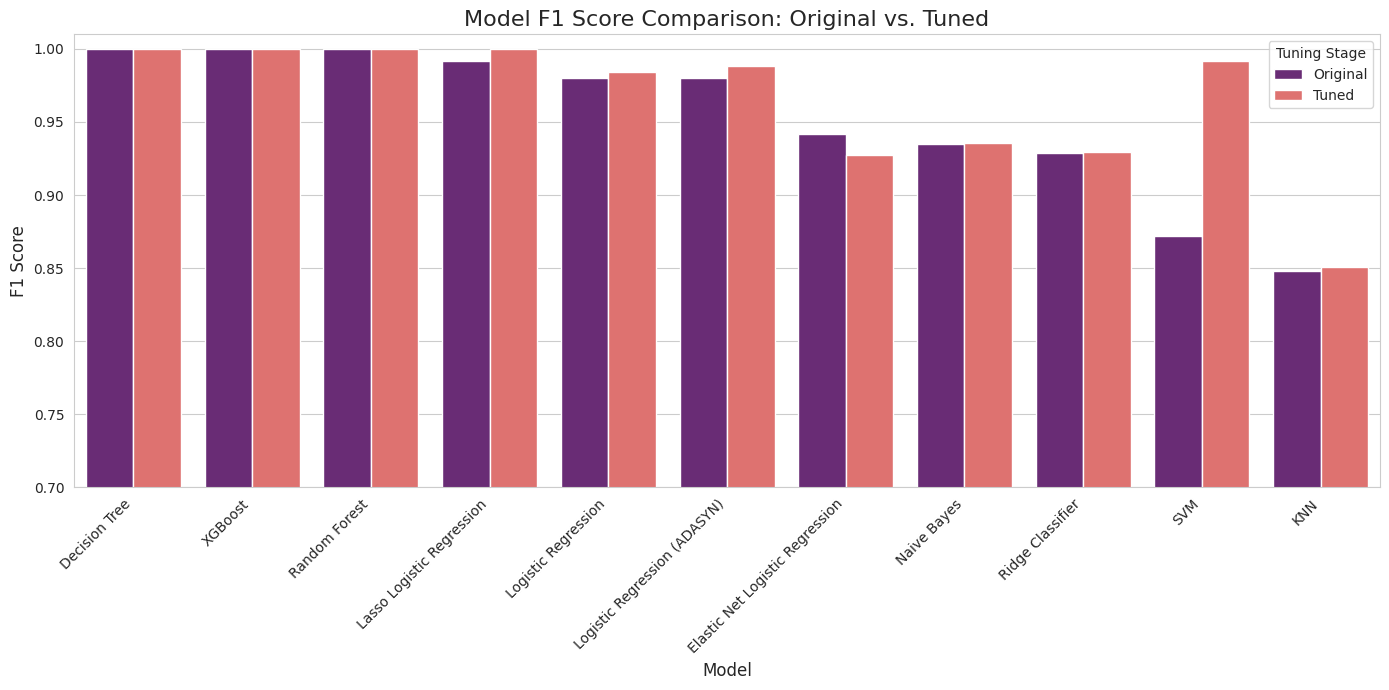

In [50]:

# Select 'Model', 'Accuracy', and 'F1 Score' from performance_df for original results
original_results = performance_df[['Model', 'Accuracy', 'F1 Score']].copy()

#Add 'Tuning Stage' column as 'Original'
original_results['Tuning Stage'] = 'Original'

#Select 'Model', 'Test Accuracy', and 'F1 Score' from grid_df for tuned results
tuned_results = grid_df[['Model', 'Accuracy', 'F1 Score']].copy()

#Add 'Tuning Stage' column as 'Tuned'
tuned_results['Tuning Stage'] = 'Tuned'

# Concatenate the original and tuned results DataFrames
comparison_df = pd.concat([original_results, tuned_results], ignore_index=True)

sns.set_style("whitegrid")
# Plot 1: Accuracy Comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='Accuracy', hue='Tuning Stage', data=comparison_df, palette='viridis')
plt.title('Model Accuracy Comparison: Original vs. Tuned', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.01)
plt.legend(title='Tuning Stage')
plt.tight_layout()
plt.show()

# Plot 2: F1 Score Comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='F1 Score', hue='Tuning Stage', data=comparison_df, palette='magma')
plt.title('Model F1 Score Comparison: Original vs. Tuned', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.01) # Adjusted y-axis limit to include SVM and KNN
plt.legend(title='Tuning Stage')
plt.tight_layout()
plt.show()

Key Findings

Four models achieved perfect performance after hyperparameter tuning: Decision Tree, XGBoost, Random Forest, and Lasso Logistic Regression.

Lasso Logistic Regression improves its Accuracy from 0.99 to 1.00.

SVM also improved substantially, with Accuracy increasing from 0.825 to 0.990.

Logistic Regression showed slight improvements in Accuracy.

Logistic Regression (ADASYN) also improved in Accuracy 0.97 to 0.98.

Elastic Net Logistic Regression saw a slight decrease in performance post-tuning, with Accuracy falling from 0.92 to 0.90.

KNN's performance slightly improved after tuning, with Accuracy rising.

Naive Bayes and Ridge Classifier performance remained static.


1. DT, RF, XGBoost, and Lasso Logistic Regression performed well.
2. For Anemia classification, the important feature is to look for Hemoglobin.
3. Random Forest, Decision Tree, XGBoost Lasso Logistic Regression, and SVM are our final models, as this gives the highest F1 score of 100% on test datasets.

###6. Saving the model and comparision

In [51]:
import joblib

joblib.dump(dt, "best_decision_tree_model.pkl")

['best_decision_tree_model.pkl']

In [52]:
comparison_df.to_csv("model_performance_comparison.csv", index=False)

In [53]:
performance_df.to_csv("performance_measures.csv", index=False)


In [54]:
grid_df.to_csv("grid_search_results.csv", index=False)
